Interpretar os resultados, incluindo a importância das variáveis.

Criar uma conclusão estratégica apontando os principais fatores que influenciam a evasão.

# Importação de Bibliotecas utilizadas neste notebook

In [1]:
# Dados
import pandas as pd

# Cálculos
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Modelos
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier    # KNN
from sklearn.preprocessing import MinMaxScaler        # Utilizado para normalização
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.linear_model import LogisticRegression


# Preparação dos Dados

## Carga de Dados - Obtenção do Arquivo Tratado

In [2]:
# Obter dados já tratados em Desafio Telecom X - parte 1
dados = pd.read_csv('https://raw.githubusercontent.com/Ronaldo-Pardini/TelecomX_parte2/refs/heads/main/Dados_TelecomX_tratados.csv')
dados.head(3)

,customerID,Churn,Gênero,Cliente Senior,Possui parceiro(a),Possui Dependentes,Meses de Contrato,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Tipo de Contrato,Conta Digital,Método de Pagamento,Gasto Mensal,Gasto Total,Gasto Diário
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,...,False,True,True,False,One year,True,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,...,False,False,False,True,Month-to-month,False,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,...,True,False,False,False,Month-to-month,True,Electronic check,73.9,280.85,2.46


## Remoção de Colunas Irrelevantes

In [3]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customerID           7043 non-null   object 
 1   Churn                7043 non-null   bool   
 2   Gênero               7043 non-null   object 
 3   Cliente Senior       7043 non-null   bool   
 4   Possui parceiro(a)   7043 non-null   bool   
 5   Possui Dependentes   7043 non-null   bool   
 6   Meses de Contrato    7043 non-null   int64  
 7   PhoneService         7043 non-null   bool   
 8   MultipleLines        7043 non-null   bool   
 9   InternetService      7043 non-null   object 
 10  OnlineSecurity       7043 non-null   bool   
 11  OnlineBackup         7043 non-null   bool   
 12  DeviceProtection     7043 non-null   bool   
 13  TechSupport          7043 non-null   bool   
 14  StreamingTV          7043 non-null   bool   
 15  StreamingMovies      7043 non-null   b

In [4]:
# Excluir colunas que não serão parte do estudo
dados.drop(columns=['customerID'], inplace=True)

In [5]:
# Avaliar conteúdo das colunas
Lista = []

for col in dados.columns:
  print(f'{col}: {dados[col].nunique()}')
  if dados[col].nunique() < 50:
    print(dados[col].unique())
  else:
    Lista.append(col)
    print('Muitos registros únicos para imprimir.')
  print('-' * 50)

dados[Lista].describe()


Churn: 2
[False  True]
--------------------------------------------------
Gênero: 2
['Female' 'Male']
--------------------------------------------------
Cliente Senior: 2
[False  True]
--------------------------------------------------
Possui parceiro(a): 2
[ True False]
--------------------------------------------------
Possui Dependentes: 2
[ True False]
--------------------------------------------------
Meses de Contrato: 73
Muitos registros únicos para imprimir.
--------------------------------------------------
PhoneService: 2
[ True False]
--------------------------------------------------
MultipleLines: 2
[False  True]
--------------------------------------------------
InternetService: 3
['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity: 2
[False  True]
--------------------------------------------------
OnlineBackup: 2
[ True False]
--------------------------------------------------
DeviceProtection: 2
[False  True]
--------------------

,Meses de Contrato,Gasto Mensal,Gasto Total,Gasto Diário
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158675
std,24.559481,30.090047,2266.794470,1.003088
min,0.000000,18.250000,0.000000,0.610000
25%,9.000000,35.500000,398.550000,1.180000
50%,29.000000,70.350000,1394.550000,2.340000
75%,55.000000,89.850000,3786.600000,2.990000
max,72.000000,118.750000,8684.800000,3.960000


Será necessário transformar dados booleanos False/True para 0/1 e também os dados categóricos (utilizaremos o OneHotEncoder).

## Transformação de Dados

### Transformação de Campos Booleanos com True/False para formato numérico 0/1

In [6]:
# Identificando colunas em formato booleano
colunas_booleanas = dados.select_dtypes(include='bool').columns

# Em todas as colunas booleanas, trocar True por 1 e False por 0
dados[colunas_booleanas] = dados[colunas_booleanas].astype(int)
dados.head(3)

,Churn,Gênero,Cliente Senior,Possui parceiro(a),Possui Dependentes,Meses de Contrato,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Tipo de Contrato,Conta Digital,Método de Pagamento,Gasto Mensal,Gasto Total,Gasto Diário
0,0,Female,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0,Male,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,1,Male,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46


### Transformação de Campos Categóricos para formato numérico
Transformando as variáveis categóricas em formato numérico para torná-las compatíveis com algoritmos de machine learning.

In [7]:
# Carregar variável alvo e explicativas
X = dados.drop(columns=['Churn'], axis=1)
y = dados['Churn']

In [8]:
# Guardar nomes originais das colunas
colunas = X.columns

# Identificar colunas categóricas
colunas_categoricas = list(X.select_dtypes(include='object').columns)
colunas_categoricas

['Gênero', 'InternetService', 'Tipo de Contrato', 'Método de Pagamento']

In [9]:
# Transformando as variáveis explicativas CATEGÓRICAS com OneHotEncoder
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['Gênero', 'InternetService', 'Tipo de Contrato', 'Método de Pagamento']
),
    remainder = 'passthrough',
    sparse_threshold=0)

X = one_hot.fit_transform(X)

In [10]:
# Visualizar como ficaram os nomes das colunas
one_hot.get_feature_names_out(colunas)

array(['onehotencoder__Gênero_Male', 'onehotencoder__InternetService_DSL',
       'onehotencoder__InternetService_Fiber optic',
       'onehotencoder__InternetService_No',
       'onehotencoder__Tipo de Contrato_Month-to-month',
       'onehotencoder__Tipo de Contrato_One year',
       'onehotencoder__Tipo de Contrato_Two year',
       'onehotencoder__Método de Pagamento_Bank transfer (automatic)',
       'onehotencoder__Método de Pagamento_Credit card (automatic)',
       'onehotencoder__Método de Pagamento_Electronic check',
       'onehotencoder__Método de Pagamento_Mailed check',
       'remainder__Cliente Senior', 'remainder__Possui parceiro(a)',
       'remainder__Possui Dependentes', 'remainder__Meses de Contrato',
       'remainder__PhoneService', 'remainder__MultipleLines',
       'remainder__OnlineSecurity', 'remainder__OnlineBackup',
       'remainder__DeviceProtection', 'remainder__TechSupport',
       'remainder__StreamingTV', 'remainder__StreamingMovies',
       'remainde

In [11]:
# Visualizar resultados da transformação em formato DataFrame para CONFERÊNCIA
dados_tratados = pd.DataFrame(X, columns = one_hot.get_feature_names_out(colunas))
dados_tratados['Churn'] = y
dados_tratados.head(3)

,onehotencoder__Gênero_Male,onehotencoder__InternetService_DSL,onehotencoder__InternetService_Fiber optic,onehotencoder__InternetService_No,onehotencoder__Tipo de Contrato_Month-to-month,onehotencoder__Tipo de Contrato_One year,onehotencoder__Tipo de Contrato_Two year,onehotencoder__Método de Pagamento_Bank transfer (automatic),onehotencoder__Método de Pagamento_Credit card (automatic),onehotencoder__Método de Pagamento_Electronic check,...,remainder__OnlineBackup,remainder__DeviceProtection,remainder__TechSupport,remainder__StreamingTV,remainder__StreamingMovies,remainder__Conta Digital,remainder__Gasto Mensal,remainder__Gasto Total,remainder__Gasto Diário,Churn
0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,0.0,1.0,65.6,593.30,2.19,0
1,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,59.9,542.40,2.00,0
2,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,73.9,280.85,2.46,1


In [12]:
dados_tratados.info()    # Conferência

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 28 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   onehotencoder__Gênero_Male                                    7043 non-null   float64
 1   onehotencoder__InternetService_DSL                            7043 non-null   float64
 2   onehotencoder__InternetService_Fiber optic                    7043 non-null   float64
 3   onehotencoder__InternetService_No                             7043 non-null   float64
 4   onehotencoder__Tipo de Contrato_Month-to-month                7043 non-null   float64
 5   onehotencoder__Tipo de Contrato_One year                      7043 non-null   float64
 6   onehotencoder__Tipo de Contrato_Two year                      7043 non-null   float64
 7   onehotencoder__Método de Pagamento_Bank transfer (automatic)  7043 no

## Verificação da Proporção de Evasão

Avaliar se há desequilíbrio entre as classes, o que pode impactar modelos preditivos e a análise de resultados.

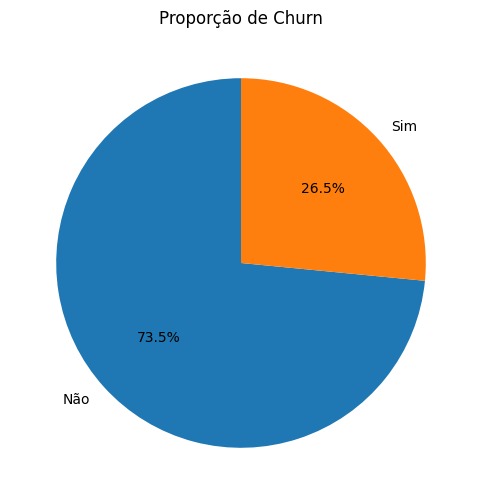

In [13]:
# Calcula proporções
proporcao = dados['Churn'].value_counts(normalize=True)

# Ajusta os rótulos
labels = ['Não', 'Sim']

# Gráfico de pizza
plt.figure(figsize=(6,6))
plt.pie(
    proporcao,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Proporção de Churn')
plt.show()

Dados levemente desbalanceados, utilizarei o parâmetro "stratify" ao realizar a separação dos dados em Treino e Teste para ajustar os modelos.  Não vejo necessidade de aplicar undersampling ou oversampling neste estudo.

# Correlação e Seleção de Variáveis

## Análise de Correlação

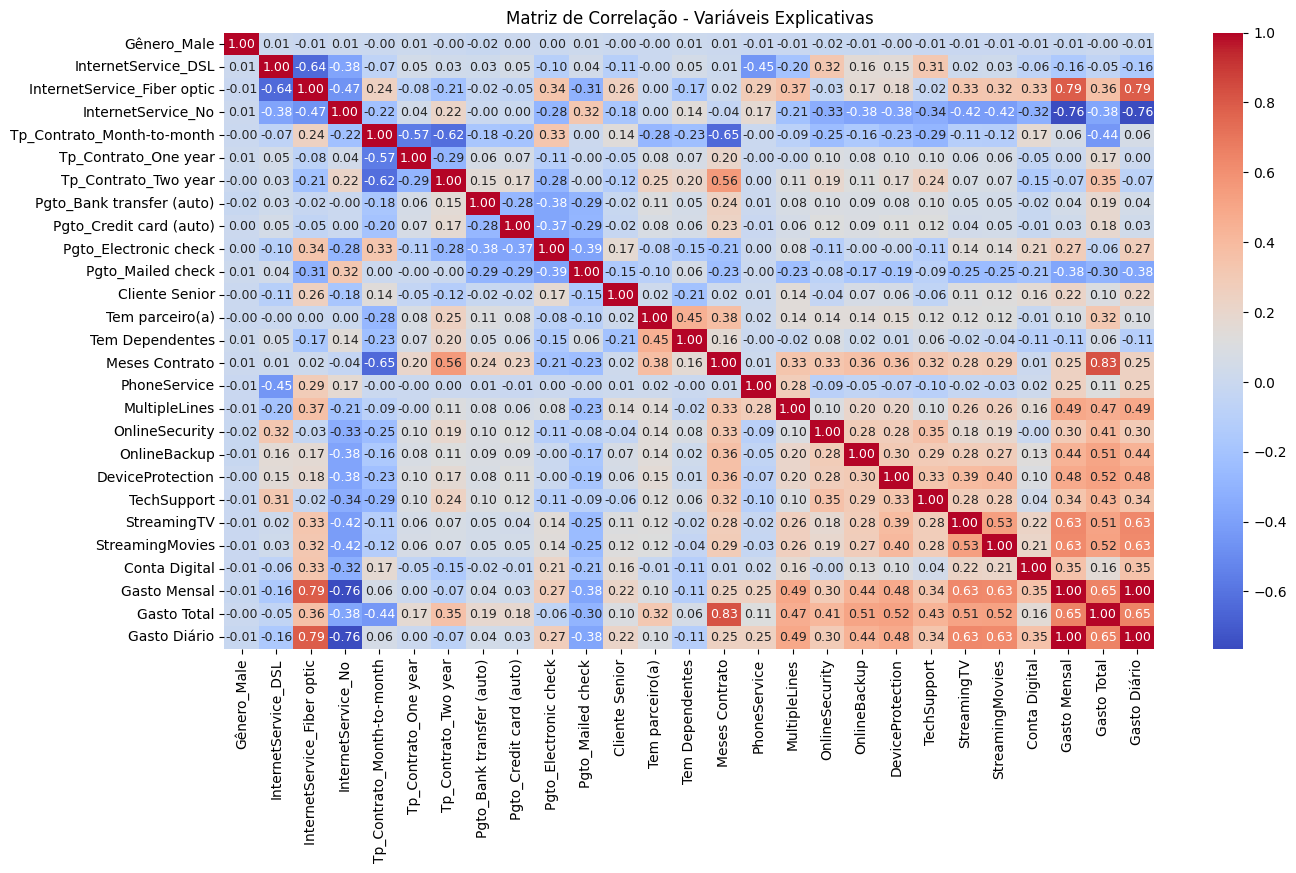

In [14]:
# Análise da correlação entre Variáveis explicativas
corr = dados_tratados.drop('Churn', axis=1).corr(method='pearson')

# Aplicando nomes mais amigáveis as colunas para faciliar a leitura do gráfico
corr_colunas = ['Gênero_Male',
 'InternetService_DSL',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Tp_Contrato_Month-to-month',
 'Tp_Contrato_One year',
 'Tp_Contrato_Two year',
 'Pgto_Bank transfer (auto)',
 'Pgto_Credit card (auto)',
 'Pgto_Electronic check',
 'Pgto_Mailed check',
 'Cliente Senior',
 'Tem parceiro(a)',
 'Tem Dependentes',
 'Meses Contrato',
 'PhoneService',
 'MultipleLines',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Conta Digital',
 'Gasto Mensal',
 'Gasto Total',
 'Gasto Diário']

corr.index = corr_colunas
corr.columns = corr_colunas

# Visualizar em formato heatmap
plt.figure(figsize=(15,8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size": 9} )
plt.title("Matriz de Correlação - Variáveis Explicativas")
plt.show()

Mediante os resultados acima, excluiremos do estudo a variável <font color=green>**Gasto Diário**</font> por ter alta correção com a variável <font color=green>**Gasto Mensal**</font>.

In [15]:
# Excluir variáveis por alta correlação entre si
dados_tratados.drop('remainder__Gasto Diário', axis=1, inplace=True)

## Análises Direcionadas

### Gráficos dos campos Categóricos

In [16]:
px.histogram(dados, x = 'Gênero', text_auto = True, color = 'Churn', barmode = 'group')

In [17]:
px.histogram(dados, x = 'InternetService', text_auto = True, color = 'Churn', barmode = 'group')

In [18]:
px.histogram(dados, x = 'Tipo de Contrato', text_auto = True, color = 'Churn', barmode = 'group')

In [19]:
px.histogram(dados, x = 'Método de Pagamento', text_auto = True, color = 'Churn', barmode = 'group')

### Estatísticas descritivas - Campos Numéricos

In [20]:
dados[['Meses de Contrato','Gasto Mensal','Gasto Total','Gasto Diário']].describe().round(2)

,Meses de Contrato,Gasto Mensal,Gasto Total,Gasto Diário
count,7043.00,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73,2.16
std,24.56,30.09,2266.79,1.00
min,0.00,18.25,0.00,0.61
25%,9.00,35.50,398.55,1.18
50%,29.00,70.35,1394.55,2.34
75%,55.00,89.85,3786.60,2.99
max,72.00,118.75,8684.80,3.96


In [21]:
# Boxplot da coluna Meses de Contrato x Churn
px.box(dados, x = 'Meses de Contrato', color = 'Churn')

In [22]:
# Boxplot da coluna Gasto Total x Churn
px.box(dados, x = 'Gasto Total', color = 'Churn')

In [23]:
## Boxplot da coluna Gasto Mensal x Churn
px.box(dados, x = 'Gasto Mensal', color = 'Churn')

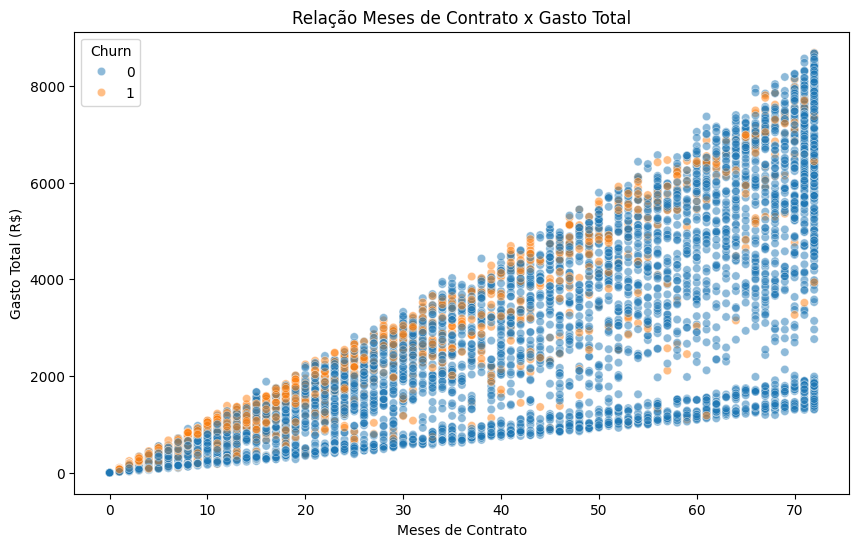

In [24]:
# Gráfico da Relação entre Meses de COntrato e Gasto Total
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Meses de Contrato', y='Gasto Total', hue='Churn', data=dados, alpha=0.5)
plt.title('Relação Meses de Contrato x Gasto Total')
plt.xlabel('Meses de Contrato')
plt.ylabel('Gasto Total (R$)')
plt.show()

# Modelagem Preditiva

## Separação de Dados

In [25]:
# Recarregar as variáveis com as colunas selecionadas para o estudo já com os tratamentos efetuados
X = dados_tratados.drop('Churn', axis=1)
y = dados_tratados['Churn']

In [26]:
# Atribuir a seleção de Treino e Teste às variáveis
# Utilizar parâmetro stratify para garantir a representatividade de registros com e sem Churn
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,stratify=y)

## Criação de Modelos

### Modelo de Base

In [27]:
dummy = DummyClassifier()
dummy.fit(X_train, y_train)

DummyClassifier()

### Modelo Árvore de decisão

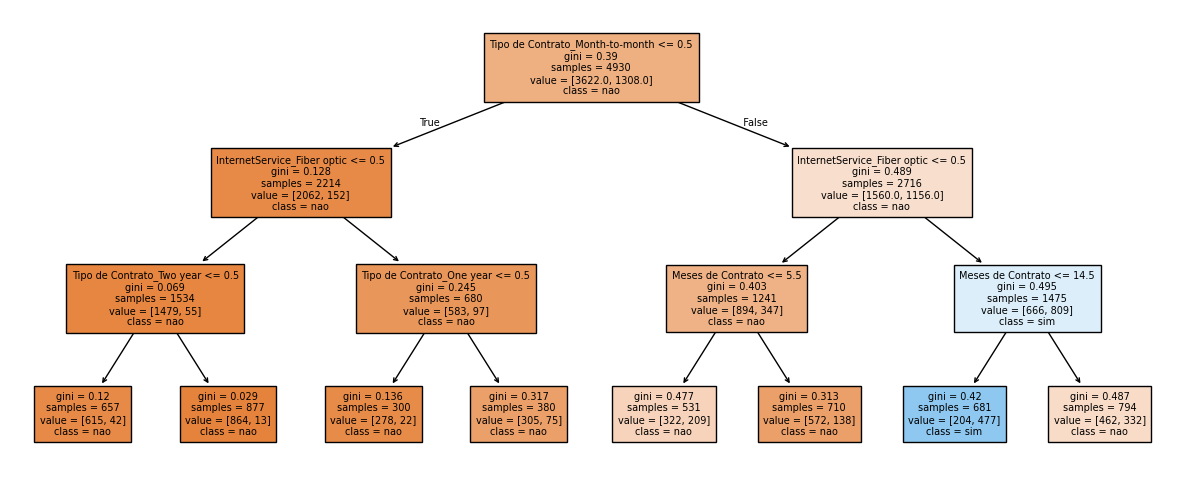

In [28]:
arvore = DecisionTreeClassifier(max_depth = 3)
arvore.fit(X_train, y_train)

# Deixar Nome das colunas mais amigável p/visualização no gráfico
nome_colunas = [c.split('__', 1)[1] for c in list(X_train.columns)]

# Gráfico da Árvore de descisão
plt.figure(figsize = (15, 6))
plot_tree(arvore, filled = True, class_names = ['nao', 'sim'], fontsize = 7, feature_names = nome_colunas);

### Modelo Random Forest

In [29]:
model_rf = RandomForestClassifier(n_estimators=200, class_weight='balanced',max_depth=8)
model_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, n_estimators=200)

### Normalizando os dados

Colunas como Meses de Contrato e Gasto Mensal possuem ampla variedade de valores que precisam ser normalizados para utilização adequada dos modelos KNN e Regressão Logística

In [30]:
dados_tratados[['remainder__Meses de Contrato','remainder__Gasto Mensal']].describe().round(2)

,remainder__Meses de Contrato,remainder__Gasto Mensal
count,7043.00,7043.00
mean,32.37,64.76
std,24.56,30.09
min,0.00,18.25
25%,9.00,35.50
50%,29.00,70.35
75%,55.00,89.85
max,72.00,118.75


In [31]:
# Normalização
normalizacao = MinMaxScaler()
x_treino_normalizado = normalizacao.fit_transform(X_train)

### Modelo KNN

In [32]:
# Aplicar método KNN
knn = KNeighborsClassifier()
knn.fit(x_treino_normalizado, y_train)

x_teste_normalizado = normalizacao.transform(X_test)
#knn.score(x_teste_normalizado, y_test)

### Modelo Regressão Logística

In [33]:
# Aplicaçao do Modelo de Regressão Logística
log_reg = LogisticRegression(max_iter=1000,class_weight="balanced")
log_reg.fit(x_treino_normalizado, y_train)

#log_reg.score(x_teste_normalizado, y_test)

LogisticRegression(class_weight='balanced', max_iter=1000)

## Avaliação dos Modelos

In [34]:
# Definir Função para cálculo das Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def avaliar_modelo(modelo, X_test, y_test):
  y_pred = modelo.predict(X_test)
  return [round(accuracy_score(y_test, y_pred)*100,2),
          round(precision_score(y_test, y_pred,zero_division=0)*100,2),
          round(recall_score(y_test, y_pred)*100,2),
          round(f1_score(y_test, y_pred)*100,2),
          confusion_matrix(y_test, y_pred)]


In [35]:
# Cria o DataFrame para armazenar as métricas
Resultados = pd.DataFrame(index=['Acurácia','Precisão','Recall','F1-score','Matriz de Confusão'])

# Obtem as métricas de cada modelo
Resultados['Dummy'] = avaliar_modelo(dummy, X_test, y_test)
Resultados['Árvore de Decisão'] = avaliar_modelo(arvore, X_test, y_test)
Resultados['KNN'] = avaliar_modelo(knn, x_teste_normalizado, y_test)
Resultados['Regressão Logística'] = avaliar_modelo(log_reg, x_teste_normalizado, y_test)
Resultados['Ramdom Forest'] = avaliar_modelo(model_rf, X_test, y_test)

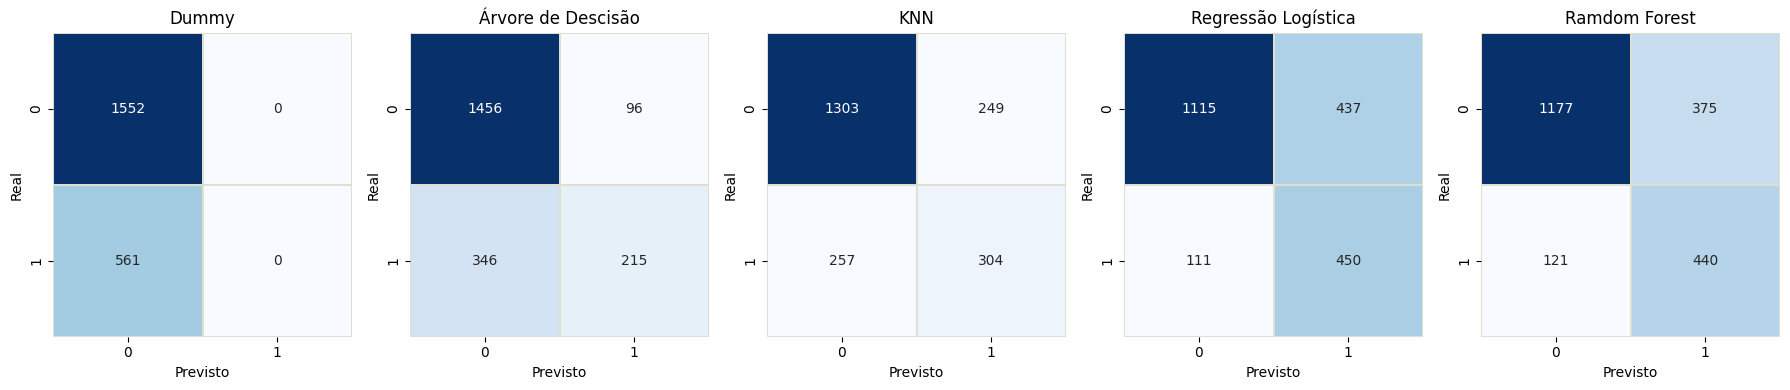

In [36]:
# Cria Representação Gráfica - Matriz de Confusão -
matrizes = Resultados.loc['Matriz de Confusão']

fig, axes = plt.subplots(1, len(matrizes), figsize=(18,4))

for ax, (modelo, matriz) in zip(axes, matrizes.items()):
    sns.heatmap(
        np.array(matriz),
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax,
        linewidths=0.2,
        linecolor='#DEDED1'
    )
    ax.set_title(modelo)
    ax.set_xlabel('Previsto')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

<b><font color=red>Material de apoio para interpretar a Matriz de Confusão</b><br></font>

<table>
  <tr>
      <td>
      <img width="800px"
           src="https://raw.githubusercontent.com/Ronaldo-Pardini/TelecomX_parte2/main/Matriz_Confus%C3%A3o_Resumida.png">
    </td>
    <td>
      <img width="800px"
           src="https://raw.githubusercontent.com/Ronaldo-Pardini/TelecomX_parte2/main/Matriz_Confus%C3%A3o_Completa.png">
    </td>
  </tr>
</table>

In [37]:
# Apresentação dos Resultados obtidos

# Emite resultados das métricas consolidadas
Resultados.drop(index="Matriz de Confusão").style.format("{:.2f}")

,Dummy,Árvore de Descisão,KNN,Regressão Logística,Ramdom Forest
Acurácia,73.45,79.08,76.05,74.07,76.53
Precisão,0.00,69.13,54.97,50.73,53.99
Recall,0.00,38.32,54.19,80.21,78.43
F1-score,0.00,49.31,54.58,62.15,63.95


### Análise Crítica dos Resultados Obtidos

Os modelos Random Forest e Regressão Logística apresentaram os melhores desempenhos gerais. O Random Forest destacou-se por apresentar maior equilíbrio entre as métricas, especialmente pelo maior F1-score, indicando uma combinação mais consistente entre Precisão e Recall.

Os modelos KNN e Árvore de Decisão, embora tenham apresentado Acurácia e Precisão relativamente elevadas, demonstraram valores inferiores de Recall. Em um contexto de Churn, esse comportamento é indesejável, pois indica uma maior probabilidade de não identificar clientes que efetivamente irão evadir, reduzindo a capacidade de atuação preventiva.

Por fim, a análise comparativa das métricas não indicou evidências de Overfitting ou Underfitting em nenhum dos modelos avaliados, sugerindo que todos apresentaram um nível adequado de generalização para o conjunto de dados analisado.

**Minha indicação: utilizar o modelo Random Forest.**

<b><font color=red>Material de apoio para interpretar as Métricas</b><br></font>
<img width="800px" src="https://raw.githubusercontent.com/Ronaldo-Pardini/TelecomX_parte2/main/Matriz_sobre_m%C3%A9tricas.jpg">

# Interpretação e Conclusões

## Análise de Importância das Variáveis

Modelo escolhido -> **Random Forest**

In [38]:
# EXtrair a importância das variáveis utilizadas no modelo Random Forest
importances = model_rf.feature_importances_

df_importancia = (
    pd.DataFrame({
        'Variável': [c.split('__', 1)[1] for c in list(X_train.columns)], # X_train.columns,
        'Importância': importances
    })
    .sort_values(by='Importância', ascending=False)
    .head(10)   # TOP 10
)

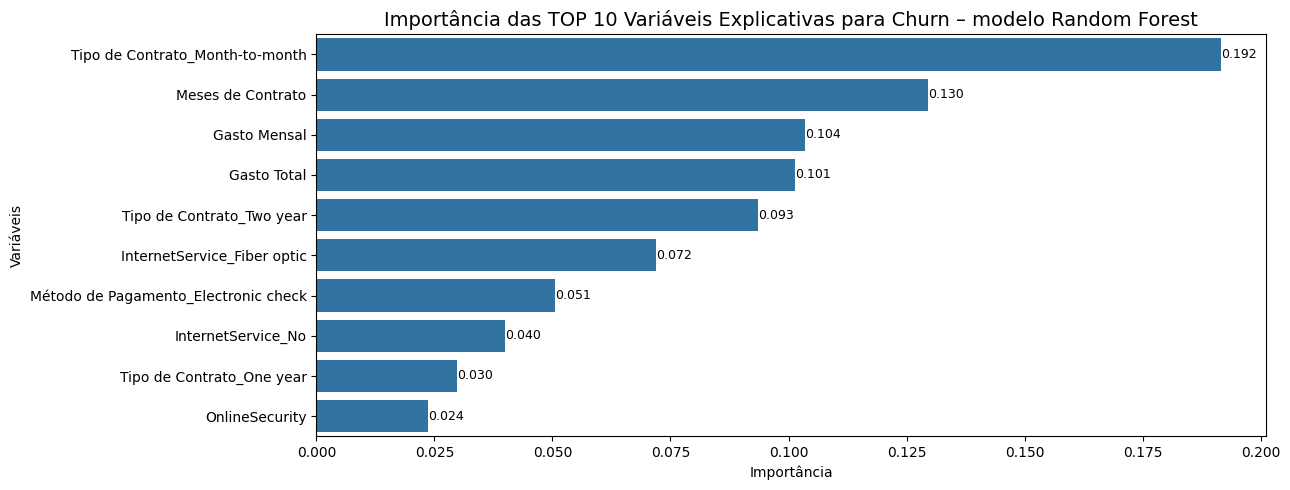

In [39]:
# Criar visualizaçao gráfica

plt.figure(figsize=(13,5))

ax = sns.barplot(
    data=df_importancia,
    x='Importância',
    y='Variável',
    orient='h'
)

# Inserir valores nas barras
for i, v in enumerate(df_importancia['Importância']):
    ax.text(
        v,
        i,
        f'{v:.3f}',
        va='center',
        fontsize=9
    )

plt.title('Importância das TOP 10 Variáveis Explicativas para Churn – modelo Random Forest', fontsize=14)
plt.xlabel('Importância')
plt.ylabel('Variáveis')
plt.tight_layout()
plt.show()

# Conclusão - Relatório

#**Relatório de Análise dos Fatores de Evasão (Churn) – Telecom X**

###**Visão Geral**


---


Com base nos modelos preditivos desenvolvidos, este estudo teve como objetivo identificar os principais fatores associados à evasão de clientes (Churn) e avaliar o desempenho comparativo dos modelos de classificação utilizados.
A análise combinou métricas quantitativas de desempenho com a interpretação das variáveis explicativas, permitindo extrair insights acionáveis para estratégias de retenção.
<br><br>
###**Avaliação do Desempenho dos Modelos**


---


Foram avaliados cinco modelos: Dummy, Árvore de Decisão, KNN, Regressão Logística e Random Forest.

- O modelo Dummy serviu apenas como linha de base, não apresentando capacidade preditiva relevante.

- Árvore de Decisão e KNN apresentaram desempenho intermediário, com boa acurácia, porém baixo Recall, o que indica dificuldade em identificar clientes que efetivamente evadem.

- A Regressão Logística apresentou Recall elevado, sendo eficiente na identificação de clientes com risco de evasão, embora com menor precisão.

- O Random Forest apresentou o melhor equilíbrio entre as métricas, destacando-se pelo maior F1-score, indicando uma relação mais balanceada entre identificar clientes evadidos e evitar falsos positivos.

**Conclusão técnica:**
O modelo Random Forest foi considerado o mais adequado para o contexto de Churn, pois equilibra capacidade preditiva, robustez e interpretabilidade dos fatores.
<br><br>
###**Principais Fatores que Influenciam a Evasão e Insights**


---


A análise das variáveis selecionadas e da importância atribuída pelo modelo Random Forest evidenciou os seguintes fatores como mais relevantes para a evasão:

**Fatores Contratuais**

- Tipo de contrato mensal (Month-to-month) apresenta forte correlação com maior evasão.

- Contratos de longo prazo (1 ou 2 anos) estão associados a menor probabilidade de Churn.

- Clientes mais recentes apresentam maior risco

- << Insight >> Clientes com vínculos mais curtos demonstram menor fidelização. O risco de churn é significativamente maior nos primeiros meses de relacionamento.

**Fatores Financeiros**

- Gasto mensal elevado aumenta a probabilidade de evasão, especialmente quando não acompanhado de percepção de valor.

- Forma de pagamento via Electronic Check apresenta associação com maior churn em comparação a métodos automáticos.

- << Insight >> Sensibilidade ao preço e obstáculos nos processos de pagamento influenciam diretamente o comportamento do cliente.

**Serviços e Experiência do Cliente**

- Ausência de serviços como Suporte Técnico (TechSupport) e Segurança Online (OnlineSecurity) está associada a maior evasão.

- Clientes com serviços adicionais ativos tendem a permanecer mais tempo.

- << Insight >> Experiência de serviço e percepção de suporte reduzem a propensão à evasão.
<br>

###**Estratégias de Retenção Recomendadas**


---


Com base nos fatores identificados, recomenda-se:

**Estratégias Comerciais**

- Incentivar migração de contratos mensais para contratos de maior prazo, com benefícios claros.

- Criar ofertas personalizadas para clientes com gasto mensal elevado, reforçando a proposta de valor.

**Estratégias Operacionais**

- Priorizar ações de retenção para clientes com: Baixo tempo de contrato e/ou  Ausência de serviços de suporte ou segurança

- Oferecer pacotes de serviços que aumentem o custo de troca e a percepção de valor.

**Estratégias Analíticas**

- Utilizar o modelo Random Forest como motor de priorização, focando em clientes com maior probabilidade prevista de churn.

- Implementar monitoramento contínuo do modelo, com reavaliação periódica das variáveis e métricas.
<br>

###**Conclusão**


---


Os resultados demonstram que a evasão de clientes na Telecom X é fortemente influenciada por fatores contratuais, financeiros e de experiência do cliente.
A adoção de modelos preditivos, em especial o Random Forest, permite não apenas prever o churn, mas também orientar estratégias práticas de retenção, contribuindo diretamente para a redução de perdas e aumento do valor do ciclo de vida do cliente.